In [1]:
import pandas as pd

df = pd.read_csv("flipkart_sales_dataset.csv")
df.head()

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Sub_Category,Brand,Customer_ID,Customer_City,Customer_State,...,Final_Price,Revenue,Profit,Shipping_Cost,Delivery_Time_Days,Return_Status,Customer_Rating,Seller_Name,Festival_Season,Platform_Device
0,OD4436250254,21-10-2023,P822594,Decathlon Yoga OI80,Sports,Yoga,Decathlon,C9306452,Ranchi,Jharkhand,...,3518.37,17591.85,4981.89,158.63,4,No,4.0,EcomGuru Sellers,Diwali Sale,App
1,OD7880063642,22-09-2023,P716718,ITC Personal CA49,Grocery,Personal Care,ITC,C3602821,Hyderabad,Telangana,...,1378.95,1378.95,215.75,23.13,4,No,NaN,EcomGuru Sellers,Regular,App
2,OD1559761787,20-06-2025,P862914,Nirlep Kitchen GA69,Home & Kitchen,Kitchen Appliances,Nirlep,C3637130,Solapur,Maharashtra,...,3974.69,3974.69,646.20,66.26,3,No,4.0,RetailNet India,Regular,App
3,OD9411947383,04-03-2024,P593328,Lakme Men's VR45,Beauty,Men's Grooming,Lakme,C3714828,Gwalior,Madhya Pradesh,...,184.46,184.46,93.97,74.23,6,No,5.0,EcomGuru Sellers,Regular,App
4,OD0960691640,22-03-2023,P577087,Rupa Academic YR16,Books,Academic,Rupa,C1880989,Ranchi,Jharkhand,...,117.18,117.18,35.63,34.42,5,No,4.0,BharatSellers,Holi Sale,App


In [5]:
# Convert date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Create new columns
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')

# What is the total revenue and profit for each year (2023–2025)?

In [6]:
yearly = df.groupby('Year')[['Revenue','Profit']].sum().reset_index()
yearly

,Year,Revenue,Profit
0,2023,3.686222e+08,8.221604e+07
1,2024,4.229765e+08,9.407855e+07
2,2025,4.721793e+08,1.041930e+08


# What is the month-over-month (MoM) growth % in revenue?

In [7]:
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()

monthly['MoM_Growth_%'] = monthly['Revenue'].pct_change() * 100
monthly.head()

,Year,Month,Revenue,MoM_Growth_%
0,2023,1,29198745.74,NaN
1,2023,2,22797252.96,-21.923862
2,2023,3,30318301.80,32.991031
3,2023,4,28484353.87,-6.048980
4,2023,5,27822879.06,-2.322239


# What is Highest & Lowest Sales Month?

In [8]:
highest_month = monthly.loc[monthly['Revenue'].idxmax()]
lowest_month = monthly.loc[monthly['Revenue'].idxmin()]

print("Highest Sales Month:\n", highest_month)
print("\nLowest Sales Month:\n", lowest_month)

Highest Sales Month:
 Year            2.025000e+03
Month           1.000000e+01
Revenue         6.675931e+07
MoM_Growth_%    9.849356e+01
Name: 33, dtype: float64

Lowest Sales Month:
 Year            2.023000e+03
Month           6.000000e+00
Revenue         2.219680e+07
MoM_Growth_%   -2.022106e+01
Name: 5, dtype: float64


# List Top 10 Products by Revenue

In [9]:
top_products = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

Product_Name
Boat Smartphones XW48      14420034.55
Boat Laptops VU17          13146310.21
Boat Laptops ES80          13133686.45
Xiaomi Smartphones GU68    12505514.99
JBL Cameras WJ30           11925649.17
Hometown Sofas UB56        11174439.48
LG Headphones WC34         11134277.38
Samsung Tablets DR85       11014113.00
LG Smart NP87              10786948.52
Realme Tablets CP88        10173227.72
Name: Revenue, dtype: float64

# Product Growth % (2024 → 2025)

In [10]:
product_year = df.groupby(['Product_Name','Year'])['Revenue'].sum().reset_index()

pivot = product_year.pivot(index='Product_Name', columns='Year', values='Revenue')

pivot['Growth_%'] = ((pivot[2025] - pivot[2024]) / pivot[2024]) * 100

pivot.sort_values(by='Growth_%', ascending=False).head(10)

Year,2023,2024,2025,Growth_%
Product_Name,,,,
Realme TV ZM16,188259.83,117666.16,560659.02,376.482805
Nirlep Furniture VB70,579690.94,142365.89,644229.89,352.517025
Philips Bedding SG93,151772.15,69949.02,238273.65,240.639011
Noise Headphones VJ46,2895270.00,1099305.00,3687130.00,235.405552
Britannia Snacks TJ49,21556.13,16659.22,53677.90,222.211364
Durian Wardrobes HR34,302110.72,290179.20,851684.64,193.502994
DSC Cycling SB18,11732.04,9373.29,27384.96,192.159530
Marico Beverages NN31,15115.94,7906.82,22723.40,187.389874
Godrej Health TS72,20684.26,24207.37,66562.17,174.966549


# Category-wise Revenue

In [11]:
category = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
category

Category
Electronics       4.805543e+08
Furniture         4.417322e+08
Sports            1.355225e+08
Home & Kitchen    1.221104e+08
Fashion           3.910368e+07
Beauty            2.929641e+07
Books             7.783526e+06
Grocery           7.675035e+06
Name: Revenue, dtype: float64

# Category Contribution %

In [12]:
category_percent = (category / df['Revenue'].sum()) * 100
category_percent

Category
Electronics       38.025214
Furniture         34.953304
Sports            10.723597
Home & Kitchen     9.662333
Fashion            3.094189
Beauty             2.318161
Books              0.615893
Grocery            0.607309
Name: Revenue, dtype: float64

# Profit Margin by Category

In [13]:
cat_profit = df.groupby('Category')[['Revenue','Profit']].sum()

cat_profit['Profit_Margin_%'] = (cat_profit['Profit'] / cat_profit['Revenue']) * 100

cat_profit

,Revenue,Profit,Profit_Margin_%
Category,,,
Beauty,2.929641e+07,1.204331e+07,41.108472
Books,7.783526e+06,2.157701e+06,27.721388
Electronics,4.805543e+08,5.118237e+07,10.650694
Fashion,3.910368e+07,1.434923e+07,36.695351
Furniture,4.417322e+08,1.313230e+08,29.729108
Grocery,7.675035e+06,1.056020e+06,13.759154
Home & Kitchen,1.221104e+08,3.099673e+07,25.384176
Sports,1.355225e+08,3.737924e+07,27.581584


# Discount Impact

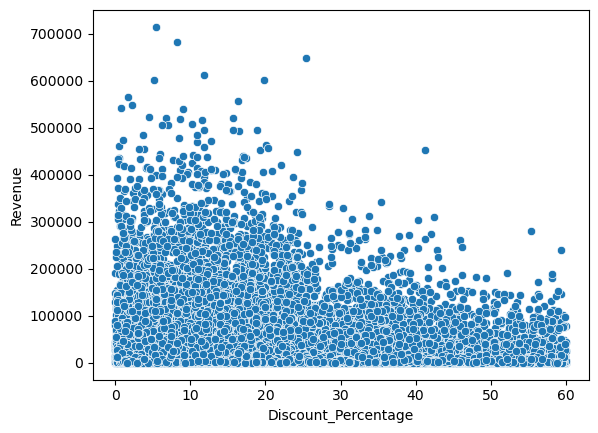

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='Discount_Percentage', y='Revenue')
plt.show()

# Top Cities

In [15]:
top_cities = df.groupby('Customer_City')['Revenue'].sum().sort_values(ascending=False).head(10)
top_cities

Customer_City
Nagpur        32926406.99
Kanpur        29550588.79
Coimbatore    29086614.06
Pune          28810417.70
Meerut        28241908.91
Chennai       27842786.77
Ranchi        27496564.11
Jabalpur      27277807.88
Aurangabad    26906229.67
Ahmedabad     26783085.96
Name: Revenue, dtype: float64

# Repeat Customer Rate

In [16]:
repeat = df['Customer_ID'].value_counts()
repeat_rate = (repeat[repeat > 1].count() / df['Customer_ID'].nunique()) * 100

print("Repeat Customer %:", repeat_rate)

Repeat Customer %: 87.72051193358699


# Festival Sales Impact

In [17]:
festival_sales = df.groupby('Festival_Season')['Revenue'].sum()
festival_sales

Festival_Season
Big Billion Days         4.347895e+07
Christmas & New Year     4.700845e+07
Diwali Sale              1.123348e+08
Holi Sale                2.620439e+07
Independence Day Sale    2.299111e+07
New Year Sale            2.242413e+07
Regular                  6.441220e+08
Republic Day Sale        1.242849e+07
Valentine's Week         1.918235e+07
Weekend Sale             3.136033e+08
Name: Revenue, dtype: float64

# Return Rate %

In [18]:
return_rate = df['Return_Status'].value_counts(normalize=True) * 100
return_rate

Return_Status
No     92.03
Yes     7.97
Name: proportion, dtype: float64

# Revenue Loss Due to Returns

In [19]:
returned = df[df['Return_Status'] == 'Returned']['Revenue'].sum()
total = df['Revenue'].sum()

print("Loss %:", (returned / total) * 100)

Loss %: 0.0


# Delivery Time vs Rating

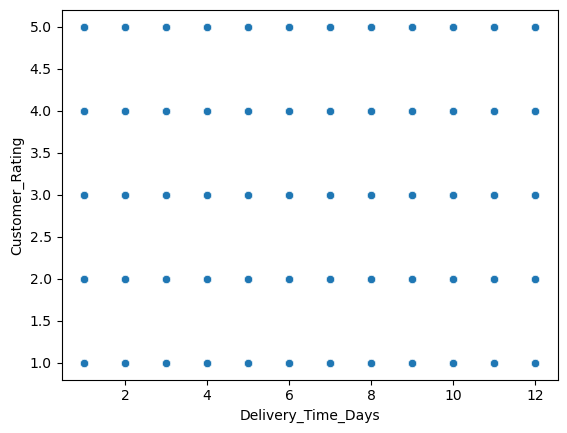

In [20]:
sns.scatterplot(data=df, x='Delivery_Time_Days', y='Customer_Rating')
plt.show()

# Platform-wise Sales

In [21]:
platform = df.groupby('Platform_Device')['Revenue'].sum()
platform

Platform_Device
App           1.041420e+09
Desktop       9.392180e+07
Mobile Web    1.284365e+08
Name: Revenue, dtype: float64

# Seller Performance

In [22]:
seller = df.groupby('Seller_Name')[['Revenue','Profit']].sum().sort_values(by='Revenue', ascending=False)
seller.head(10)

,Revenue,Profit
Seller_Name,,
QuickMart Pvt Ltd,89569636.81,20516617.16
HomeEssentials India,89027913.75,19770147.33
TechZone Sellers,86941027.40,19445632.34
PrimeDeals India,86128272.70,18875484.10
MegaStore Online,85568159.34,18995498.08
Shopify Traders,85231802.38,18684754.21
EcomGuru Sellers,83995178.42,18614731.36
TrendSetters Online,83626176.98,18209225.87
ValueMart Sellers,83107701.84,18775332.46


# Average Order Value (AOV)

In [23]:
aov = df['Revenue'].sum() / df['Order_ID'].nunique()
print("AOV:", aov)

AOV: 25275.559723599996


# Customer Lifetime Value (CLV)

In [24]:
clv = df.groupby('Customer_ID')['Revenue'].sum().mean()
print("CLV:", clv)

CLV: 87428.43211207195


# Monthly Trend Graph

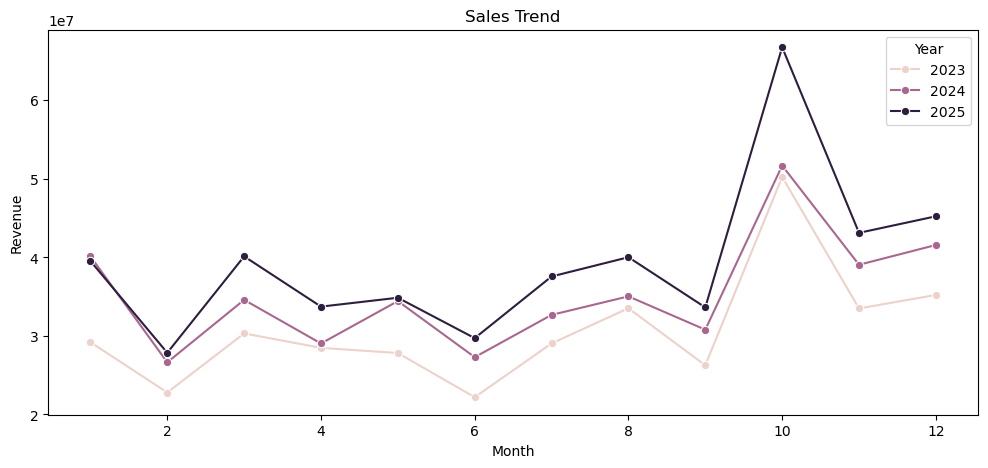

In [25]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='Month', y='Revenue', hue='Year', marker='o')
plt.title("Sales Trend")
plt.show()